Dataset Loaded Successfully
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Missing Values Handled

===== Simple Linear Regression =====
MSE  : 0.7108067152364504
RMSE : 0.8430935388415988
R2 Score : 0.45756879948224916


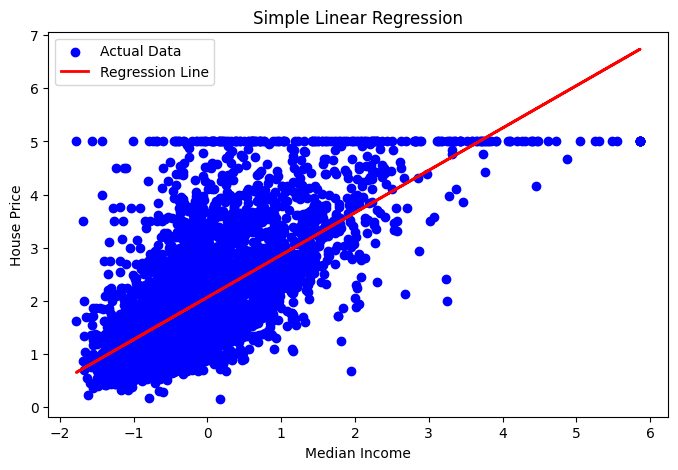


===== Multiple Linear Regression =====
MSE  : 0.5573234433137074
RMSE : 0.7465409856891364
R2 Score : 0.5746950360017667


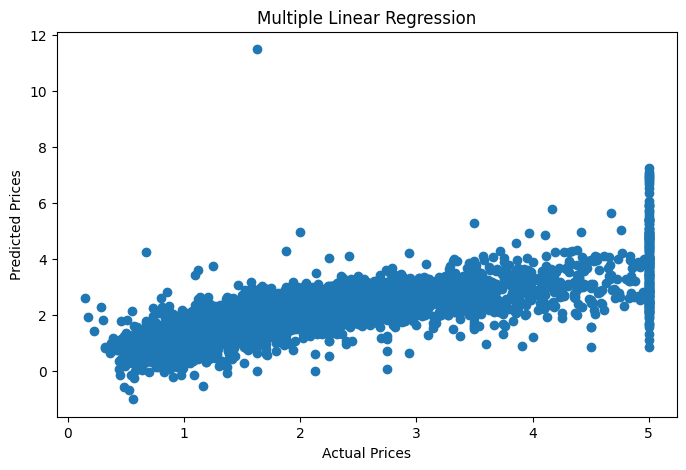


Feature Coefficients
      Feature  Coefficient
0      MedInc     0.851583
1    HouseAge     0.122406
2    AveRooms    -0.303741
3   AveBedrms     0.369900
4  Population    -0.002229
5    AveOccup    -0.036622
6    Latitude    -0.897158
7   Longitude    -0.869551

=========== FINAL COMPARISON ===========

Simple Linear Regression
RMSE : 0.8430935388415988
R2 Score : 0.45756879948224916

Multiple Linear Regression
RMSE : 0.7465409856891364
R2 Score : 0.5746950360017667


In [1]:
# ==========================================
# Assignment No. 2
# Simple & Multiple Linear Regression
# Using sklearn (Built-in Dataset)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------

data = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Target Variable
df['Price'] = data.target

print("Dataset Loaded Successfully")
print(df.head())

# ------------------------------------------
# 2. Handle Missing Values
# ------------------------------------------

# Artificially creating some missing values
df.iloc[0:10, 0] = np.nan

# Imputer
imputer = SimpleImputer(strategy='mean')

df.iloc[:, :-1] = imputer.fit_transform(df.iloc[:, :-1])

print("\nMissing Values Handled")

# ------------------------------------------
# 3. Feature Scaling
# ------------------------------------------

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df.iloc[:, :-1])

X_scaled = pd.DataFrame(
    scaled_features,
    columns=data.feature_names
)

# ------------------------------------------
# 4. Simple Linear Regression
# Predicting House Price using MedInc
# ------------------------------------------

X_simple = X_scaled[['MedInc']]
y = df['Price']

# Train-Test Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y,
    test_size=0.2,
    random_state=42
)

# Model
simple_model = LinearRegression()

# Train
simple_model.fit(X_train_s, y_train_s)

# Predictions
y_pred_s = simple_model.predict(X_test_s)

# ------------------------------------------
# 5. Evaluation - Simple Linear Regression
# ------------------------------------------

mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test_s, y_pred_s)

print("\n===== Simple Linear Regression =====")
print("MSE  :", mse_s)
print("RMSE :", rmse_s)
print("R2 Score :", r2_s)

# ------------------------------------------
# 6. Visualization - Regression Line
# ------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(X_test_s, y_test_s, color='blue', label='Actual Data')

plt.plot(
    X_test_s,
    y_pred_s,
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# ------------------------------------------
# 7. Multiple Linear Regression
# Using All Features
# ------------------------------------------

X_multiple = X_scaled

# Train-Test Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multiple, y,
    test_size=0.2,
    random_state=42
)

# Model
multiple_model = LinearRegression()

# Train
multiple_model.fit(X_train_m, y_train_m)

# Predictions
y_pred_m = multiple_model.predict(X_test_m)

# ------------------------------------------
# 8. Evaluation - Multiple Linear Regression
# ------------------------------------------

mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

print("\n===== Multiple Linear Regression =====")
print("MSE  :", mse_m)
print("RMSE :", rmse_m)
print("R2 Score :", r2_m)

# ------------------------------------------
# 9. Actual vs Predicted Visualization
# ------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(y_test_m, y_pred_m)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Multiple Linear Regression")

plt.show()

# ------------------------------------------
# 10. Coefficients
# ------------------------------------------

coeff_df = pd.DataFrame({
    'Feature': X_multiple.columns,
    'Coefficient': multiple_model.coef_
})

print("\nFeature Coefficients")
print(coeff_df)

# ------------------------------------------
# 11. Final Comparison
# ------------------------------------------

print("\n=========== FINAL COMPARISON ===========")

print("\nSimple Linear Regression")
print("RMSE :", rmse_s)
print("R2 Score :", r2_s)

print("\nMultiple Linear Regression")
print("RMSE :", rmse_m)
print("R2 Score :", r2_m)

# ------------------------------------------
# END
# ------------------------------------------